## Parte I — 01. Descrição do Dataset

**Unidade Curricular:** Laboratório de Analise de Dados 
**Dataset:** NBA Stats (1947–2026) — [Kaggle](https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats)  

---

### Contexto da Aplicação

Vamos criar uma plataforma de análise de dados de basquetebol profissional que serve múltiplos perfis de utilizador: scouts e analistas de clubes, agentes de jogadores, jornalistas desportivos e fãs. A plataforma permite explorar estatísticas históricas desde 1947, comparar jogadores entre eras, descobrir talentos emergentes, prever reconhecimento individual (MVP, All-Star, Hall of Fame) e entre muitos outros aspetos

---

### Objetivos deste Notebook

1. Carregar e inspecionar todos os ficheiros CSV do dataset  
2. Caracterizar cada ficheiro (domínio, dimensão, tipos de dados, entidades)  
3. Identificar e tratar valores nulos e duplicados  
4. Construir o dataset principal através de merges informados  
5. Guardar o dataset consolidado para uso nos notebooks seguintes  

---
## Instalação de dependências e imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Paths
DATA_DIR = './data/'
OUTPUT_DIR = './outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Estilo global dos gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})
PALETTE = ['#C9082A', '#1D428A', '#FFC72C', '#007A33', '#552583']  # Cores predominantes da NBA

---
## Inventário dos Ficheiros CSV

O dataset é composto por 22 ficheiros CSV organizados em três categorias:
- Ficheiros de jogador — estatísticas individuais por época
- Ficheiros de equipa — estatísticas agregadas por equipa/época  
- Ficheiros contextuais — prémios, draft, All-Stars, carreira

In [23]:
# Listar todos os ficheiros CSV disponíveis
csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])

print(f"Total de ficheiros CSV encontrados: {len(csv_files)}\n")
for i, f in enumerate(csv_files, 1):
    size_kb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1024
    print(f"  {i:2d}. {f:<45} ({size_kb:6.1f} KB)")

Total de ficheiros CSV encontrados: 22

   1. Advanced.csv                                  (4511.8 KB)
   2. All-Star Selections.csv                       (  88.4 KB)
   3. Draft Pick History.csv                        ( 443.0 KB)
   4. End of Season Teams (Voting).csv              ( 316.7 KB)
   5. End of Season Teams.csv                       ( 106.2 KB)
   6. Opponent Stats Per 100 Poss.csv               ( 210.4 KB)
   7. Opponent Stats Per Game.csv                   ( 262.7 KB)
   8. Opponent Totals.csv                           ( 266.0 KB)
   9. Per 100 Poss.csv                              (4119.0 KB)
  10. Per 36 Minutes.csv                            (4502.4 KB)
  11. Player Award Shares.csv                       ( 205.5 KB)
  12. Player Career Info.csv                        ( 496.3 KB)
  13. Player Per Game.csv                           (4568.3 KB)
  14. Player Play By Play.csv                       (1728.6 KB)
  15. Player Season Info.csv                        (1442.7 KB)


---
## Caracterização Individual de Cada Ficheiro

Para cada ficheiro inspecionamos: dimensão (linhas × colunas), tipos de dados, percentagem de valores nulos e uma amostra dos dados.

In [24]:
# Função utilitária para inspecionar um CSV de forma padronizada
def inspect_csv(filename, data_dir=DATA_DIR):
    path = os.path.join(data_dir, filename)
    df = pd.read_csv(path, low_memory=False)
    
    total_cells = df.shape[0] * df.shape[1]
    null_count = df.isnull().sum().sum()
    null_pct = round(null_count / total_cells * 100, 1) if total_cells > 0 else 0
    
    return {
        'ficheiro': filename,
        'linhas': df.shape[0],
        'colunas': df.shape[1],
        'nulos_%': null_pct,
        'tipos': dict(df.dtypes.astype(str).value_counts()),
        'colunas_lista': list(df.columns),
        'df': df
    }

print("A carregar todos os ficheiros...")
datasets = {}
for f in csv_files:
    datasets[f] = inspect_csv(f)
    print(f"  ✓ {f}")
print("\nTodos os ficheiros carregados.")

A carregar todos os ficheiros...
  ✓ Advanced.csv
  ✓ All-Star Selections.csv
  ✓ Draft Pick History.csv
  ✓ End of Season Teams (Voting).csv
  ✓ End of Season Teams.csv
  ✓ Opponent Stats Per 100 Poss.csv
  ✓ Opponent Stats Per Game.csv
  ✓ Opponent Totals.csv
  ✓ Per 100 Poss.csv
  ✓ Per 36 Minutes.csv
  ✓ Player Award Shares.csv
  ✓ Player Career Info.csv
  ✓ Player Per Game.csv
  ✓ Player Play By Play.csv
  ✓ Player Season Info.csv
  ✓ Player Shooting.csv
  ✓ Player Totals.csv
  ✓ Team Abbrev.csv
  ✓ Team Stats Per 100 Poss.csv
  ✓ Team Stats Per Game.csv
  ✓ Team Summaries.csv
  ✓ Team Totals.csv

Todos os ficheiros carregados.


In [25]:
# Tabela resumo de todos os ficheiros
summary_rows = []
for f, meta in datasets.items():
    summary_rows.append({
        'Ficheiro'    : f.replace('.csv', ''),
        'Linhas'      : meta['linhas'],
        'Colunas'     : meta['colunas'],
        'Nulos (%)'   : meta['nulos_%'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Linhas', ascending=False)
summary_df = summary_df.reset_index(drop=True)
summary_df.index += 1

# Colorir a coluna de nulos
def color_nulls(val):
    if val < 2:   
        color = '#d4edda'
    elif val < 8: 
        color = '#fff3cd'
    else:         
        color = '#f8d7da'
    return f'background-color: {color}; color: black'

summary_df.style \
    .applymap(color_nulls, subset=['Nulos (%)']) \
    .format({'Linhas': '{:,}', 'Nulos (%)': '{:.1f}%'}) \
    .set_caption('Inventário completo dos ficheiros CSV do dataset')

,Ficheiro,Linhas,Colunas,Nulos (%)
1,Advanced,"33,278",30,8.2%
2,Player Totals,"33,278",33,8.0%
3,Player Season Info,"33,278",8,0.5%
4,Player Per Game,"33,278",32,8.3%
5,Per 36 Minutes,"32,195",1,0.0%
6,Per 100 Poss,"27,631",34,2.6%
7,Player Shooting,"18,193",32,3.6%
8,Player Play By Play,"18,193",26,1.0%
9,Draft Pick History,"8,383",8,1.3%
10,Player Career Info,"5,396",11,0.7%


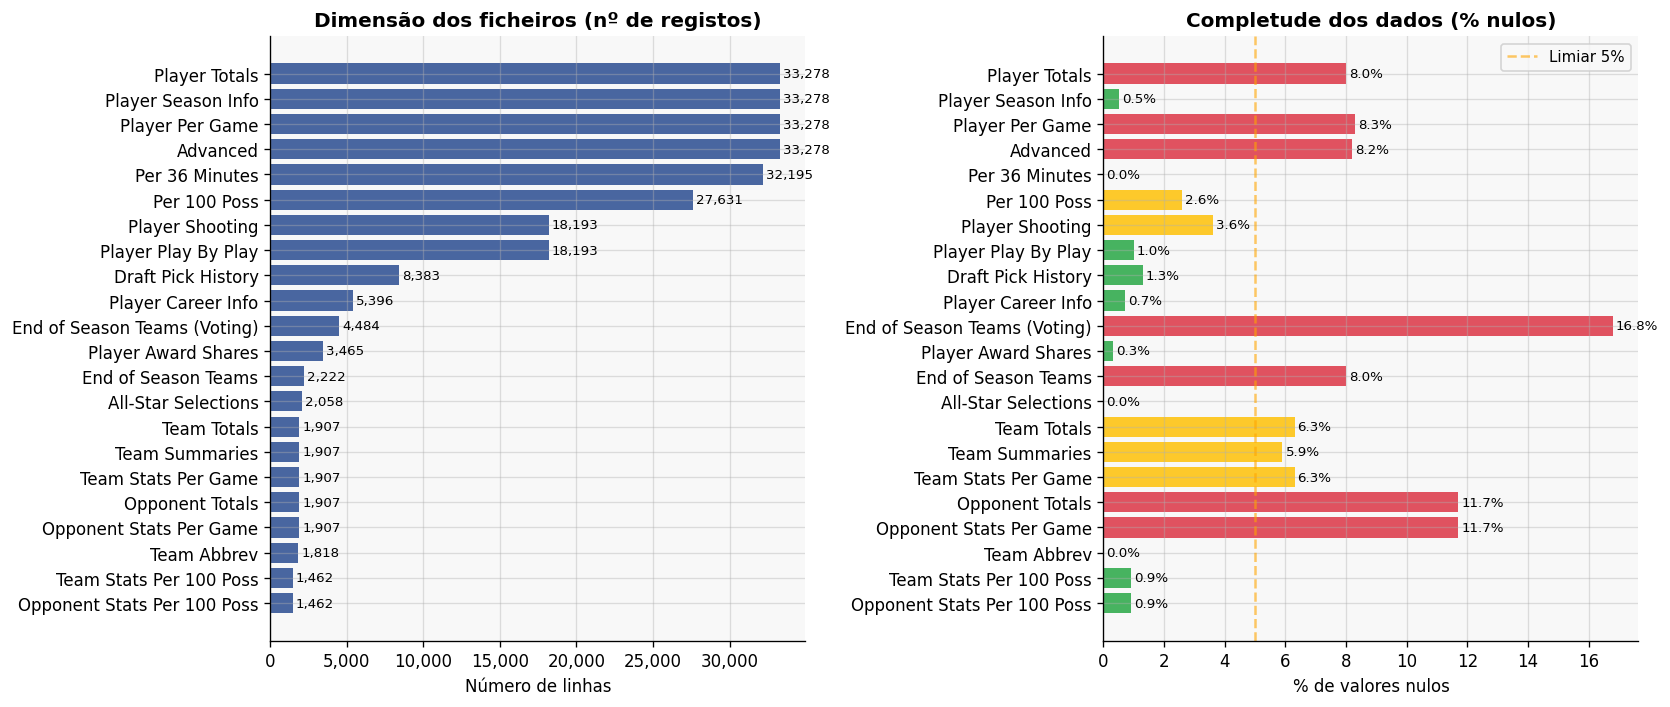

In [26]:
# Visualização da dimensão de cada ficheiro 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

nomes  = [r['Ficheiro'].replace('.csv','') for r in summary_rows]
linhas = [r['Linhas'] for r in summary_rows]
nulos  = [r['Nulos (%)'] for r in summary_rows]

# Ordenar por nº de linhas
ordem = sorted(range(len(linhas)), key=lambda i: linhas[i])
nomes_ord  = [nomes[i]  for i in ordem]
linhas_ord = [linhas[i] for i in ordem]
nulos_ord  = [nulos[i]  for i in ordem]

# Gráfico 1 — Nº de linhas por ficheiro
bars = axes[0].barh(nomes_ord, linhas_ord, color='#1D428A', alpha=0.8)
axes[0].set_xlabel('Número de linhas')
axes[0].set_title('Dimensão dos ficheiros (nº de registos)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, linhas_ord):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)

# Gráfico 2 — % de nulos por ficheiro
colors_n = ['#28a745' if n < 2 else '#ffc107' if n < 8 else '#dc3545' for n in nulos_ord]
bars2 = axes[1].barh(nomes_ord, nulos_ord, color=colors_n, alpha=0.85)
axes[1].set_xlabel('% de valores nulos')
axes[1].set_title('Completude dos dados (% nulos)', fontweight='bold')
axes[1].axvline(x=5, color='orange', linestyle='--', alpha=0.6, label='Limiar 5%')
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, nulos_ord):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}01_dimensao_ficheiros.png', bbox_inches='tight')
plt.show()

---
## Descrição Detalhada dos Ficheiros Principais

Inspecionamos em detalhe os ficheiros que vão constituir o dataset de trabalho.

In [27]:
# Player Per Game 
ppg = datasets['Player Per Game.csv']['df'].copy()

print("PLAYER PER GAME")
print(f"Dimensão: {ppg.shape[0]:,} linhas × {ppg.shape[1]} colunas")
print(f"Épocas: {ppg['season'].min()} a {ppg['season'].max()}")
print(f"Ligas: {sorted(ppg['lg'].unique())}")
print(f"Posições: {sorted(ppg['pos'].dropna().unique())}")
print(f"Jogadores únicos: {ppg['player_id'].nunique():,}")
print(f"\nTipos de dados:")
for dtype, count in ppg.dtypes.value_counts().items():
    print(f"  {str(dtype)} - {count} colunas")
print(f"\nNulos por coluna (só as que têm nulos):")
nulls = ppg.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
for col, n in nulls.items():
    print(f"  {col}: {n:,} ({n/len(ppg)*100:.1f}%)")
print(f"\nAmostra (5 linhas):")
ppg.head(5)

PLAYER PER GAME
Dimensão: 33,278 linhas × 32 colunas
Épocas: 1947 a 2026
Ligas: ['ABA', 'BAA', 'NBA']
Posições: ['C', 'PF', 'PG', 'SF', 'SG']
Jogadores únicos: 5,396

Tipos de dados:
  float64 - 25 colunas
  object - 5 colunas
  int64 - 2 colunas

Nulos por coluna (só as que têm nulos):
  x3p_percent: 10,623 (31.9%)
  gs: 8,178 (24.6%)
  x2p_percent: 6,596 (19.8%)
  e_fg_percent: 6,499 (19.5%)
  x3pa_per_game: 6,353 (19.1%)
  x2p_per_game: 6,352 (19.1%)
  x2pa_per_game: 6,352 (19.1%)
  x3p_per_game: 6,352 (19.1%)
  tov_per_game: 5,636 (16.9%)
  stl_per_game: 5,602 (16.8%)
  blk_per_game: 5,600 (16.8%)
  orb_per_game: 4,646 (14.0%)
  drb_per_game: 4,646 (14.0%)
  ft_percent: 1,384 (4.2%)
  pos: 1,197 (3.6%)
  mp_per_game: 1,083 (3.3%)
  trb_per_game: 894 (2.7%)
  fg_percent: 166 (0.5%)
  age: 20 (0.1%)
  pf_per_game: 1 (0.0%)

Amostra (5 linhas):


,season,lg,player,player_id,age,team,pos,g,gs,mp_per_game,...,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,53,37.0,21.2,...,0.532,2.1,3.7,5.8,1.2,0.9,0.6,0.7,1.7,8.1
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,22.8,...,0.580,4.5,4.1,8.6,1.5,0.7,0.6,1.1,1.7,5.8
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,53,53.0,31.4,...,0.765,2.1,7.8,9.9,2.8,1.0,0.7,1.8,1.6,18.6
3,2026,NBA,Ochai Agbaji,agbajoc01,25.0,2TM,SG,49,13.0,15.5,...,0.839,0.8,1.5,2.3,0.8,0.4,0.3,0.4,1.6,4.5
4,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,42,13.0,15.5,...,0.862,0.8,1.5,2.3,0.7,0.4,0.3,0.5,1.8,4.3


In [28]:
# Advanced 
adv = datasets['Advanced.csv']['df'].copy()

print("ADVANCED STATS")
print(f"Dimensão: {adv.shape[0]:,} linhas × {adv.shape[1]} colunas")
print(f"\nMétricas avançadas disponíveis:")
adv_metrics = {
    'per': 'Player Efficiency Rating — eficiência global normalizada para a média da liga (15.0)',
    'ts_percent': 'True Shooting % — eficiência de remate contando 2pts, 3pts e lances livres',
    'usg_percent': 'Usage Rate — % das posses da equipa usadas pelo jogador em campo',
    'ws': 'Win Shares — estimativa de vitórias contribuídas pelo jogador na época',
    'ws_48': 'Win Shares por 48 minutos — normalizado pelo tempo de jogo',
    'bpm': 'Box Plus/Minus — contribuição estimada por 100 posses vs média da liga',
    'vorp': 'Value Over Replacement Player — valor acima de um jogador de substituição',
    'obpm': 'Offensive Box Plus/Minus',
    'dbpm': 'Defensive Box Plus/Minus',
    'ows': 'Offensive Win Shares',
    'dws': 'Defensive Win Shares',
}
for col, desc in adv_metrics.items():
    if col in adv.columns:
        print(f"  {col}: {desc}")
print(f"\nNulos por coluna (só as que têm nulos):")
nulls_adv = adv.isnull().sum()
nulls_adv = nulls_adv[nulls_adv > 0].sort_values(ascending=False)
for col, n in nulls_adv.items():
    print(f"  {col}: {n:,} ({n/len(adv)*100:.1f}%)")

ADVANCED STATS
Dimensão: 33,278 linhas × 30 colunas

Métricas avançadas disponíveis:
  per: Player Efficiency Rating — eficiência global normalizada para a média da liga (15.0)
  ts_percent: True Shooting % — eficiência de remate contando 2pts, 3pts e lances livres
  usg_percent: Usage Rate — % das posses da equipa usadas pelo jogador em campo
  ws: Win Shares — estimativa de vitórias contribuídas pelo jogador na época
  ws_48: Win Shares por 48 minutos — normalizado pelo tempo de jogo
  bpm: Box Plus/Minus — contribuição estimada por 100 posses vs média da liga
  vorp: Value Over Replacement Player — valor acima de um jogador de substituição
  obpm: Offensive Box Plus/Minus
  dbpm: Defensive Box Plus/Minus
  ows: Offensive Win Shares
  dws: Defensive Win Shares

Nulos por coluna (só as que têm nulos):
  gs: 8,155 (24.5%)
  x3p_ar: 6,500 (19.5%)
  tov_percent: 5,745 (17.3%)
  bpm: 5,652 (17.0%)
  dbpm: 5,652 (17.0%)
  obpm: 5,652 (17.0%)
  vorp: 5,647 (17.0%)
  usg_percent: 5,641 (17.0

In [29]:
# Player Career Info 
career = datasets['Player Career Info.csv']['df'].copy()

print("PLAYER CAREER INFO")
print(f"Dimensão: {career.shape[0]:,} jogadores únicos × {career.shape[1]} colunas")
print(f"\nVariáveis:")
career_desc = {
    'ht_in_in': 'Altura em polegadas (1 pol = 2.54 cm)',
    'wt': 'Peso em libras (1 lb ≈ 0.45 kg)',
    'birth_date': 'Data de nascimento',
    'colleges': 'Universidade(s) frequentada(s)',
    'from': 'Primeira época na NBA',
    'to': 'Última época na NBA',
    'hof': 'Hall of Fame (True/False)',
}
for col, desc in career_desc.items():
    if col in career.columns:
        print(f"  {col:<12}: {desc}")
print(f"\nJogadores no Hall of Fame: {career['hof'].sum()} ({career['hof'].mean()*100:.1f}%)")
print(f"Altura média: {career['ht_in_in'].mean()*2.54:.1f} cm")
print(f"Peso médio:   {career['wt'].mean()*0.453:.1f} kg")

PLAYER CAREER INFO
Dimensão: 5,396 jogadores únicos × 11 colunas

Variáveis:
  ht_in_in    : Altura em polegadas (1 pol = 2.54 cm)
  wt          : Peso em libras (1 lb ≈ 0.45 kg)
  birth_date  : Data de nascimento
  colleges    : Universidade(s) frequentada(s)
  from        : Primeira época na NBA
  to          : Última época na NBA
  hof         : Hall of Fame (True/False)

Jogadores no Hall of Fame: 177 (3.3%)
Altura média: 198.1 cm
Peso médio:   95.0 kg


In [30]:
# Team Summaries 
teams = datasets['Team Summaries.csv']['df'].copy()

print("TEAM SUMMARIES")
print(f"Dimensão: {teams.shape[0]:,} linhas × {teams.shape[1]} colunas")
print(f"Épocas: {teams['season'].min()} a {teams['season'].max()}")
print(f"Equipas únicas: {teams['team'].nunique()}")
print(f"Épocas com playoffs: {teams['playoffs'].sum()} registos")
print(f"\nMétricas-chave:")
team_desc = {
    'w/l': 'Vitórias e derrotas na época regular',
    'o_rtg': 'Offensive Rating — pontos marcados por 100 posses',
    'd_rtg': 'Defensive Rating — pontos sofridos por 100 posses',
    'n_rtg': 'Net Rating — diferença entre o_rtg e d_rtg',
    'pace': 'Ritmo — posses por 48 minutos',
    'srs': 'Simple Rating System — qualidade ajustada da equipa',
    'playoffs': 'Se a equipa chegou aos playoffs',
    'attend_g': 'Assistência média por jogo',
}
for col, desc in team_desc.items():
    print(f"  {col}: {desc}")

TEAM SUMMARIES
Dimensão: 1,907 linhas × 31 colunas
Épocas: 1947 a 2026
Equipas únicas: 97
Épocas com playoffs: 1051 registos

Métricas-chave:
  w/l: Vitórias e derrotas na época regular
  o_rtg: Offensive Rating — pontos marcados por 100 posses
  d_rtg: Defensive Rating — pontos sofridos por 100 posses
  n_rtg: Net Rating — diferença entre o_rtg e d_rtg
  pace: Ritmo — posses por 48 minutos
  srs: Simple Rating System — qualidade ajustada da equipa
  playoffs: Se a equipa chegou aos playoffs
  attend_g: Assistência média por jogo


---
## Análise de Valores Nulos e Duplicados

Antes de construir o dataset consolidado, tratamos os dois problemas principais identificados:
1. Valores nulos em colunas de 3 pontos (a linha dos 3pts só foi introduzida em 1980)
2. Duplicados de jogadores que mudaram de equipa a meio da época

Análise de nulos — Player Per Game
Nulos em x3p_per_game: 6,352 registos
  Épocas SEM dados de 3pts: 1947 a 1979
  Linha de 3pts introduzida na época: 1968

Conclusão: Nulos em colunas de 3pts são estruturais, ou seja, não é erro de dados.
  Tratamento: manter como NaN — representam 0 tentativas nessa era.


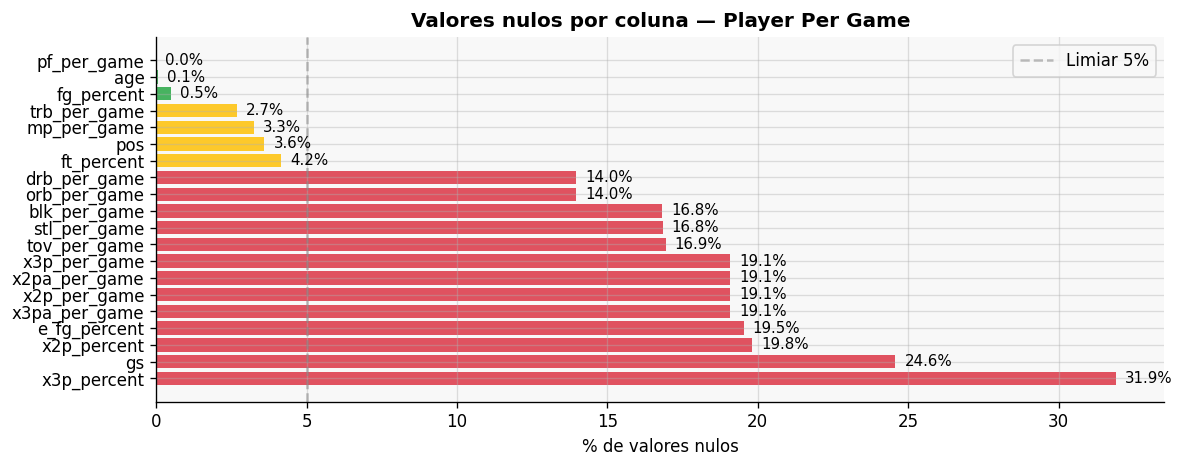

In [31]:
# Análise de nulos no Player Per Game 
print("Análise de nulos — Player Per Game")

nulls_ppg = ppg.isnull().sum()
nulls_ppg = nulls_ppg[nulls_ppg > 0].sort_values(ascending=False)

# Verificar se os nulos em x3p correspondem às épocas sem linha de 3pts
sem_3pts = ppg[ppg['x3p_per_game'].isnull()]['season'].unique()
com_3pts = ppg[ppg['x3p_per_game'].notna()]['season'].unique()
print(f"Nulos em x3p_per_game: {nulls_ppg.get('x3p_per_game', 0):,} registos")
print(f"  Épocas SEM dados de 3pts: {min(sem_3pts)} a {max(sem_3pts)}")
print(f"  Linha de 3pts introduzida na época: {min(com_3pts)}")
print(f"\nConclusão: Nulos em colunas de 3pts são estruturais, ou seja, não é erro de dados.")
print(f"  Tratamento: manter como NaN — representam 0 tentativas nessa era.")

# Ver nulos
fig, ax = plt.subplots(figsize=(10, 4))
colors_bar = ['#dc3545' if v > 10 else '#ffc107' if v > 2 else '#28a745'
              for v in (nulls_ppg / len(ppg) * 100)]
bars = ax.barh(nulls_ppg.index, nulls_ppg.values / len(ppg) * 100, color=colors_bar, alpha=0.85)
ax.set_xlabel('% de valores nulos')
ax.set_title('Valores nulos por coluna — Player Per Game', fontweight='bold')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.5, label='Limiar 5%')
ax.legend()
for bar, val in zip(bars, nulls_ppg.values / len(ppg) * 100):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}01_nulos_ppg.png', bbox_inches='tight')
plt.show()

In [32]:
# Análise e tratamento de duplicados 
print("Análise de duplicados — Player Per Game")

dup_mask = ppg.duplicated(subset=['player_id', 'season'], keep=False)
dupls = ppg[dup_mask]
print(f"Registos com player_id+season duplicados: {len(dupls):,}")
print(f"Jogadores afectados: {dupls['player_id'].nunique():,}")
print(f"\nExplicação: jogadores que mudaram de equipa a meio da época.")
print(f"  Cada jogador tem: 1 linha por equipa + 1 linha '2TM'/'3TM' com totais combinados.")
print(f"\nExemplo:")
exemplo = ppg[ppg['player_id'] == 'abdelal01'][['season','player','team','pts_per_game']]
print(exemplo.to_string(index=False))

print(f"\nEstratégia adotada:")
print(f"   Manter apenas a linha '2TM'/'3TM'")
print(f"   Para jogadores sem troca de equipa, manter o único registo existente")

# Valores de team que representam totais combinados
multi_teams = ppg[ppg['team'].isin(['2TM', '3TM'])]['team'].value_counts()
print(f"\nLinhas de totais combinados: {multi_teams.to_dict()}")

Análise de duplicados — Player Per Game
Registos com player_id+season duplicados: 9,428
Jogadores afectados: 2,123

Explicação: jogadores que mudaram de equipa a meio da época.
  Cada jogador tem: 1 linha por equipa + 1 linha '2TM'/'3TM' com totais combinados.

Exemplo:
 season         player team  pts_per_game
   1995 Alaa Abdelnaby  2TM           4.7
   1995 Alaa Abdelnaby  SAC           5.0
   1995 Alaa Abdelnaby  PHI           0.7
   1994 Alaa Abdelnaby  BOS           4.9
   1993 Alaa Abdelnaby  2TM           7.7
   1993 Alaa Abdelnaby  MIL           5.3
   1993 Alaa Abdelnaby  BOS           8.2
   1992 Alaa Abdelnaby  POR           6.1
   1991 Alaa Abdelnaby  POR           3.1

Estratégia adotada:
   Manter apenas a linha '2TM'/'3TM'
   Para jogadores sem troca de equipa, manter o único registo existente

Linhas de totais combinados: {'2TM': 2832, '3TM': 203}


---
## Construção do Dataset Consolidado

Aplicamos a deduplicação e fazemos os merges entre os ficheiros principais para criar um dataset único e rico para análise.

In [33]:
# Função de deduplicação 
def deduplicate_players(df):
    """
    Para jogadores que mudaram de equipa numa época - Mantém apenas a linha '2TM' ou '3TM' (totais combinados)
    Para jogadores sem mudança de equipa - Mantém o único registo existente
    """
    multi = df[df['team'].isin(['2TM', '3TM'])]
    single = df[~df.duplicated(subset=['player_id', 'season'], keep=False)]
    result = pd.concat([single, multi]).drop_duplicates(subset=['player_id', 'season'])
    return result.sort_values(['season', 'player']).reset_index(drop=True)


# Carregar e desduplicar ficheiros base 
ppg_clean = deduplicate_players(ppg.copy())
adv_clean = deduplicate_players(datasets['Advanced.csv']['df'].copy())
total_clean = deduplicate_players(datasets['Player Totals.csv']['df'].copy())

print(f"Player Per Game:{len(ppg)} - {len(ppg_clean)} registos")
print(f"Advanced:{len(datasets['Advanced.csv']['df'])} - {len(adv_clean)} registos")
print(f"Player Totals:{len(datasets['Player Totals.csv']['df'])} - {len(total_clean)} registos")

Player Per Game:33278 - 26885 registos
Advanced:33278 - 26885 registos
Player Totals:33278 - 26885 registos


In [34]:
# Merge principal 
print("A construir o dataset consolidado...\n")

# Base: Player Per Game 
df = ppg_clean.copy()
print(f"Base (Player Per Game): {df.shape}")

# 2Advanced Stats 
adv_cols = ['player_id', 'season', 'per', 'ts_percent', 'usg_percent', 'ows', 'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp']
df = df.merge(adv_clean[adv_cols], on=['player_id', 'season'], how='left')
print(f" Advanced Stats: {df.shape}")

# Player Totals 
tot_cols = ['player_id', 'season', 'team', 'trp_dbl']
df = df.merge(total_clean[tot_cols], on=['player_id', 'season', 'team'], how='left')
print(f"Player Totals (trp_dbl): {df.shape}")

# Player Career Info 
career_clean = datasets['Player Career Info.csv']['df'].copy()
career_cols = ['player_id', 'ht_in_in', 'wt', 'birth_date', 'hof', 'from', 'to', 'colleges']
df = df.merge(career_clean[career_cols], on='player_id', how='left')
print(f"+ Player Career Info: {df.shape}")

# Player Season Info 
season_info = datasets['Player Season Info.csv']['df'].copy()
si_cols = ['player_id', 'season', 'experience']
df = df.merge(season_info[si_cols], on=['player_id', 'season'], how='left')
print(f"Player Season Info: {df.shape}")

print(f"\nDataset consolidado final: {df.shape[0]:,} registos × {df.shape[1]} colunas")

A construir o dataset consolidado...

Base (Player Per Game): (26885, 32)
 Advanced Stats: (26885, 43)
Player Totals (trp_dbl): (26885, 44)
+ Player Career Info: (26885, 51)
Player Season Info: (33163, 52)

Dataset consolidado final: 33,163 registos × 52 colunas


In [35]:
# Adicionar flag All-Star 
allstar = datasets['All-Star Selections.csv']['df'][['player_id', 'season']].copy()
allstar['is_allstar'] = True
df = df.merge(allstar, on=['player_id', 'season'], how='left')
df['is_allstar'] = df['is_allstar'].fillna(False)

total_allstar = df['is_allstar'].sum()
print(f"All-Star selections adicionadas: {total_allstar:,} ({total_allstar/len(df)*100:.1f}% dos registos)")

# Adicionar flag playoffs 
teams_summ = datasets['Team Summaries.csv']['df'][['abbreviation', 'season', 'playoffs']].copy()
teams_summ = teams_summ.rename(columns={'abbreviation': 'team', 'playoffs': 'team_playoffs'})
df = df.merge(teams_summ, on=['team', 'season'], how='left')

print(f"Flag team_playoffs adicionada.")
print(f"\nDataset final: {df.shape[0]:,} registos × {df.shape[1]} colunas")

All-Star selections adicionadas: 2,152 (6.5% dos registos)
Flag team_playoffs adicionada.

Dataset final: 33,163 registos × 54 colunas


In [36]:
# Conversões de unidades 
# polegadas para centímetros
df['height_cm'] = (df['ht_in_in'] * 2.54).round(1)

# libras para quilogramas
df['weight_kg'] = (df['wt'] * 0.453592).round(1)

# birth_date para datetime
df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')

# Remover colunas originais em unidades imperiais (mantemos as SI)
df = df.drop(columns=['ht_in_in', 'wt'], errors='ignore')

print("Conversões aplicadas:")
print(f"  ht_in_in - height_cm | Exemplo: {df['height_cm'].dropna().iloc[0]} cm")
print(f"  wt - weight_kg | Exemplo: {df['weight_kg'].dropna().iloc[0]} kg")
print(f"  birth_date - datetime")
print(f"\nDataset final: {df.shape[0]:,} × {df.shape[1]} colunas")

Conversões aplicadas:
  ht_in_in - height_cm | Exemplo: 188.0 cm
  wt - weight_kg | Exemplo: 88.5 kg
  birth_date - datetime

Dataset final: 33,163 × 54 colunas


In [37]:
# Sumário final do dataset consolidado 
print("Dataset:")
print(f"Registos totais: {df.shape[0]:,}")
print(f"Variáveis: {df.shape[1]}")
print(f"Épocas cobertas: {df['season'].min()} a {df['season'].max()}")
print(f"Ligas: {sorted(df['lg'].unique())}")
print(f"Jogadores únicos: {df['player_id'].nunique():,}")
print(f"Posições: {sorted(df['pos'].dropna().unique())}")
print(f"\nNulos por coluna (top 10):")
nulls_final = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(nulls_final.head(10).round(1).to_string())

print(f"\nVariáveis numéricas: {df.select_dtypes(include='number').shape[1]}")
print(f"Variáveis categóricas: {df.select_dtypes(include='object').shape[1]}")
print(f"Variáveis booleanas: {df.select_dtypes(include='bool').shape[1]}")
print(f"Variáveis datetime: {df.select_dtypes(include='datetime').shape[1]}")

Dataset:
Registos totais: 33,163
Variáveis: 54
Épocas cobertas: 1947 a 2026
Ligas: ['ABA', 'BAA', 'NBA']
Jogadores únicos: 5,392
Posições: ['C', 'PF', 'PG', 'SF', 'SG']

Nulos por coluna (top 10):
x3p_percent      30.4
team_playoffs    28.1
gs               24.2
x2p_percent      19.5
e_fg_percent     19.3
x3pa_per_game    19.0
x3p_per_game     19.0
x2pa_per_game    19.0
x2p_per_game     19.0
usg_percent      16.9

Variáveis numéricas: 44
Variáveis categóricas: 7
Variáveis booleanas: 2
Variáveis datetime: 1


In [38]:
# Estatísticas descritivas básicas 
print("Estatísticas descritivas das variáveis numéricas principais:\n")

cols_desc = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'mp_per_game', 'fg_percent', 'per', 'ws', 'bpm', 'vorp', 'age', 'height_cm', 'weight_kg']
cols_desc = [c for c in cols_desc if c in df.columns]

desc = df[cols_desc].describe().T
desc.columns = ['n', 'média', 'std', 'min', '25%', 'mediana', '75%', 'max']
desc = desc.round(2)
desc.style.format(precision=2).background_gradient(cmap='Blues', subset=['média'])

Estatísticas descritivas das variáveis numéricas principais:



,n,média,std,min,25%,mediana,75%,max
pts_per_game,33163.00,8.42,6.04,0.00,3.80,6.90,11.70,50.40
ast_per_game,33163.00,1.89,1.76,0.00,0.70,1.30,2.60,14.50
trb_per_game,32269.00,3.75,2.77,0.00,1.80,3.00,4.90,27.20
mp_per_game,32080.00,20.28,10.00,0.00,12.10,19.50,28.40,48.50
fg_percent,33071.00,0.43,0.09,0.00,0.39,0.44,0.48,1.00
per,32072.00,12.64,5.74,-90.60,9.90,12.70,15.60,133.80
ws,33159.00,2.50,2.95,-2.80,0.30,1.50,3.80,25.40
bpm,27565.00,-1.76,4.50,-92.10,-3.50,-1.50,0.40,242.20
vorp,27568.00,0.55,1.27,-2.60,-0.10,0.10,0.90,12.50
age,33143.00,26.47,3.86,18.00,24.00,26.00,29.00,46.00


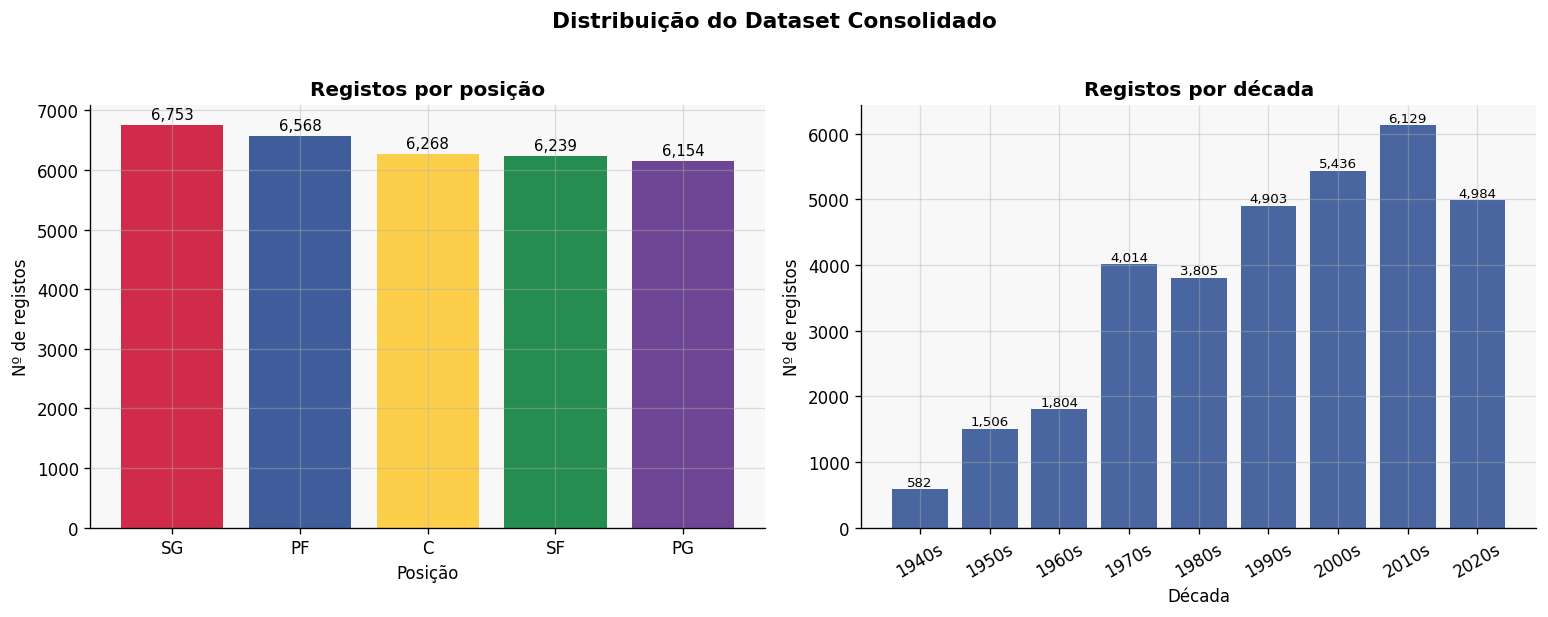

In [39]:
# Distribuição por posição e por era 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Registos por posição
pos_counts = df['pos'].value_counts().dropna()
axes[0].bar(pos_counts.index, pos_counts.values, color=['#C9082A','#1D428A','#FFC72C','#007A33','#552583'], alpha=0.85)
axes[0].set_title('Registos por posição', fontweight='bold')
axes[0].set_xlabel('Posição')
axes[0].set_ylabel('Nº de registos')
for i, (pos, val) in enumerate(pos_counts.items()):
    axes[0].text(i, val + 100, f'{val:,}', ha='center', fontsize=9)

# Registos por década
df['decade'] = (df['season'] // 10 * 10).astype(str) + 's'
dec_counts = df['decade'].value_counts().sort_index()
axes[1].bar(dec_counts.index, dec_counts.values, color='#1D428A', alpha=0.8)
axes[1].set_title('Registos por década', fontweight='bold')
axes[1].set_xlabel('Década')
axes[1].set_ylabel('Nº de registos')
axes[1].tick_params(axis='x', rotation=30)
for i, (dec, val) in enumerate(dec_counts.items()):
    axes[1].text(i, val + 50, f'{val:,}', ha='center', fontsize=8)

plt.suptitle('Distribuição do Dataset Consolidado', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}01_distribuicao_dataset.png', bbox_inches='tight')
plt.show()

In [40]:
# Filtrar apenas NBA (excluir ABA e BAA) 
print("Ligas no dataset:")
print(df['lg'].value_counts().to_string())
print()

# Mantemos ABA/BAA no dataset mas criamos uma flag
df['is_nba'] = df['lg'] == 'NBA'
df_nba = df[df['is_nba']].copy()

print(f"Dataset completo (NBA + ABA + BAA): {len(df):,} registos")
print(f"Dataset apenas NBA:{len(df_nba):,} registos")

Ligas no dataset:
lg
NBA    30987
ABA     1594
BAA      582

Dataset completo (NBA + ABA + BAA): 33,163 registos
Dataset apenas NBA:30,987 registos


---
## Guardar Datasets para Notebooks Seguintes

In [41]:
# Guardar dataset consolidado completo
df.to_csv(f'{OUTPUT_DIR}dataset_consolidado.csv', index=False)
print(f"dataset_consolidado.csv — {len(df):,} linhas × {df.shape[1]} colunas")

# Guardar versão só NBA
df_nba.to_csv(f'{OUTPUT_DIR}dataset_nba.csv', index=False)
print(f"dataset_nba.csv — {len(df_nba):,} linhas × {df_nba.shape[1]} colunas")

# Guardar Team Summaries limpo para análises de equipa
teams_summ_full = datasets['Team Summaries.csv']['df'].copy()
teams_summ_full.to_csv(f'{OUTPUT_DIR}team_summaries.csv', index=False)
print(f"team_summaries.csv — {len(teams_summ_full):,} linhas × {teams_summ_full.shape[1]} colunas")

dataset_consolidado.csv — 33,163 linhas × 56 colunas
dataset_nba.csv — 30,987 linhas × 56 colunas
team_summaries.csv — 1,907 linhas × 31 colunas


---
## Análise Crítica 

Esta secção documenta os principais pontos a ter em conta na interpretação dos resultados.

ANÁLISE CRÍTICA DO DATASET

1. NULOS ESTRUTURAIS 
   • Colunas de 3 pontos (x3p_*): nulos antes de 1980 porque a linha dos 3pts
     só foi introduzida na época 1979-80. Manter NaN ou substituir por 0.
   • Colunas de métricas avançadas (per, bpm, etc.): algumas não estão disponíveis
     para as épocas mais antigas da BAA/ABA.

2. COMPARAÇÃO ENTRE ERAS
   • O ritmo de jogo variou significativamente: anos 60 (~120 posses/jogo)
     vs anos 2000 (~90 posses/jogo) vs presente (~100 posses/jogo).
   • Comparações directas de pts_per_game entre eras são enganosas.
   • Solução: usar métricas por 100 posses para comparações históricas justas.

3. JOGADORES COM MÚLTIPLAS EQUIPAS
   • ~19% dos registos correspondem a jogadores que mudaram de equipa.
   • Estratégia adotada: manter linha '2TM'/'3TM' (totais combinados da época).
   • Implicação: a coluna 'team' para esses jogadores fica como '2TM'/'3TM'.

4. TRÊS LIGAS (NBA, ABA, BAA)
   • O dataset inclui a BAA (1947-49), ABA (1967-76) e NBA.
   • A ABA tinha regras diferentes.
   • Análises comparativas devem filtrar apenas NBA para consistência.

5. DADOS MAIS RECENTES (2026)
   • A época 2025-26 ainda está em curso — os dados são parciais.
   • Alguns jogadores têm menos jogos que o habitual.
   • Podemos considerar filtrar épocas completas para análises estatísticas.
